#7-3. 평균 이동

##7-3-1. 평균 이동의 개요

* 평균 이동은 K-평균과 유사하게 중심을 군집의 중심으로 지속적으로 움직이면서 군집화를 수행합니다.
* 하지만 K-평균이 중심에 소속된 데이터의 평균 거리 중심으로 이동하는 데 반해, 평균 이동은 중심을 데이터가 모여 있는 밀도가 가장 높은 곳으로 이동시킵니다.
* 평균 이동 군집화는 데이터의 분포도를 이용해 군집 중심점을 찾습니다.
* 군집 중심점은 데이터 포
인트가 모여있는 곳이라는 생각에서 착안한 것이며 이를 위해 확률 밀도 함수(probability density
function)를 이용합니다.
* 가장 집중적으로 데이터가 모여있어 확률 밀도 함수가 피크인 점을 군집 중심점으로 선정하며 일반적으로 주어진 모델의 확률 밀도 함수를 찾기 위해서 KDE(Kernel Density Estimation)를 이용합니다.
* 평균 이동 군집화는 특정 데이터를 반경 내의 데이터 분포 확률 밀도가 가장 높은 곳으로 이동하기 위해 주변 데이터와의 거리 값을 KDE 함수 값으로 입력한 뒤 그 반환 값을 현재 위치에서 업데이트하면서 이동하는 방식을 취합니다.
* 이러한 방식을 전체 데이터에 반복적으로 적용하면서 데이터의 군집 중심점을 찾아냅니다.
* KDE(Kernel Density Estimation)는 커널(Kern이) 함수를 통해 어떤 변수의 확률 밀도 함수를 추정
하는 대표적인 방법입니다.
* 관측된 데이터 각각에 커널 함수를 적용한 값을 모두 더한 뒤 데이터 건수로 나눠 확률 밀도 함수를 추정합니다.
* 확률 밀도 함수 PDF(Probability Density Function)는 확률
변수의 분포를 나타내는 함수로, 널리 알려진 정규분포 함수를 포함해 감마 분포, t-분포 등이 있습니다.
* 확률 밀도 함수를 알면 특정 변수가 어떤 값을 갖게 될지에 대한 확률을 알게 되므로 이를 통해 변
수의 특성(가령 정규 분포의 경우 평균, 분산), 확률 분포 등 변수의 많은 요소를 알 수 있습니다.
* KDE는 개별 관측 데이터에 커널 함수를 적용한 뒤, 이 적용 값을 모두 더한 후 개별 관측 데이터의 건수로 나눠 확률 밀도 함수를 추정하며, 대표적인 커널 함수로서 가우시안 분포 함수가 사용됩니다.
* 대역폭 h는 KDE 형태를 부드러운(또는 뾰족한) 형태로 평활화(Smoothing)하는 데 적용되며, 이 h
를 어떻게 설정하느냐에 따라 확률 밀도 추정 성능을 크게 좌우할 수 있습니다.
* 작은 h 값(h=1.0)은 좁고 뾰족한 KDE를 가지게 되며, 이는 변동성이 큰 방식으로 확률 밀도 함수를 추정하므로 과적합(over-fitting)하기 쉽습니다.
* 반대로 매우 큰 h 값(h=10)은 과도하게 평활화(smoothing)된 KDE로 인해 지나치게 단순화된 방식으로 확률 밀도 함수를 추정하며 결과적으로 과소적합(under-fitting)하기 쉽습니다.
* 따라서 적절한 KDE의 대역
폭을 계산하는 것은 KDE 기반의 평균 이동(Mean Shift) 군집화에서 매우 중요합니다.
* 일반적으로 평균 이동 군집화는 대역폭이 클수록 평활화된 KDE로 인해 적은 수의 군집 중심점을 가지
며 대역폭이 적을수록 많은 수의 군집 중심점을 가집니다.
* 또한 평균 이동 군집화는 군집의 개수를 지정하지 않으며, 오직 대역폭의 크기에 따라 군집화를 수행합니다.
* 사이킷런은 평균 이동 군집화를 위해 MeanShift 클래스를 제공합니다.
* MeanShift 클래스의 가장 중요한 초기화 파라미터는 bandwidth이
며 이 파라미터는 KDE의 대역폭 h와 동일합니다.
* 대역폭 크기 설정이 군집화의 품질에 큰 영향을 미치기 때문에 사이킷런은 최적의 대역폭 계산을 위해 estimate_bandwidth() 함수를 제공합니다.
* 다음 예제는 make_blobs()의 cluster_std를 0.7로 정한 3개 군집의 데이터에 대해 bandwidth를 0.8로 설정한 평균 이동 군집화 알고리즘을 적용한 예제입니다.

In [ ]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift
X, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.7, random_state=0 )
meanshift= MeanShift(bandwidth=0.8)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2 3 4 5]


* 군집이 0부터 5까지 6개로 분류됐습니다.
* 지나치게 세분화돼 군집화됐습니다.
* 일반적으로 bandwidth값을 작게 할수록 군집 개수가 많아집니다.
* 이번에 bandwidth를 살짝 높인 1.0으로 해서 MeanShift를 수행해 보겠습니다.

In [ ]:
meanshift= MeanShift(bandwidth=1)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


* 3개의 군집으로 잘 군집화됐습니다.
* 데이터의 분포 유형에 따라 bandwidth 값의 변화는 군집화 개수
에 큰 영향을 미칠 수 있습니다.
* 따라서 MeanShift에서는 이 bandwidth를 최적화 값으로 설정하는
것이 매우 중요합니다.
* 사이킷런은 최적화된 bandwidth 값을 찾기 위해서 estimate_bandwidth( )
함수를 제공합니다.
* estimate_bandwidth()의 파라미터로 피처 데이터 세트를 입력해주면 최적화된
bandwidth 값을 반환해줍니다.

In [ ]:
 from sklearn.cluster import estimate_bandwidth
 bandwidth = estimate_bandwidth(X)
 print('bandwidth 값:', round(bandwidth,3))

bandwidth 값: 1.816


* estimate_bandwidth( )로 측정된 bandwidth를 평균 이동 입력값으로 적용해 동일한 make_blobs() 데이터 세트에 군집화를 수행해 보겠습니다

In [ ]:
import pandas as pd
clusterDF = pd.DataFrame(data=X, columns=['ftr1','ftr2'])
clusterDF['target'] = y
# estimate_bandwidth()로 최적의 bandwidth 계산
best_bandwidth = estimate_bandwidth(X)

meanshift= MeanShift(bandwidth=best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print( 'cluster labels 유형 : ',np.unique(cluster_labels))

cluster labels 유형 :  [0 1 2]


* 3개의 군집으로 구성됨을 알 수 있습니다.
* 구성된 3개의 군집을 시각화해 보겠습니다.
* 평균 이동도 K- 평균과 유사하게 중심을 가지고 있으므로 cluster_centers_ 속성으로 군집 중심 좌표를 표시할 수 있습니다.

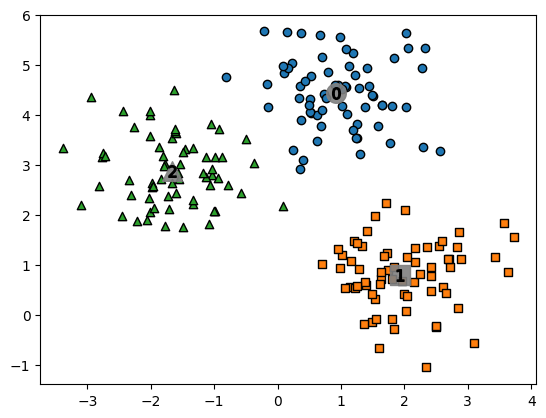

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
clusterDF['meanshift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers=['o', 's', '^','x', '*']
for label in unique_labels:
  label_cluster = clusterDF [ clusterDF ['meanshift_label' ]==label ]
  center_x_y = centers[label]
  #군집별로 다른 마커로 산점도 적용
  plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'],edgecolor='k', marker=markers[label])
  # 군집별 중심 표현
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9, marker=markers[label])
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', marker='$%d$' % label)
plt.show()

* target 값과 군집 label 값을 비교해 보겠습니다. Target 값과 군집 label 값이 1:1로 잘 매칭됐습니다.

In [ ]:
print(clusterDF.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       1                  67
2       2                  66
Name: count, dtype: int64


* 평균 이동의 장점은 데이터 세트의 형태를 특정 형태로 가정한다든가, 특정 분포도 기반의 모델로 가정하지 않기 때문에 좀 더 유연한 군집화가 가능한 것입니다.
* 또한 이상치의 영향력도 크지 않으며, 미리 군집의 개수를 정할 필요도 없습니다.
* 하지만 알고리즘의 수행 시간이 오래 걸리고 무엇보다도 band-
width의 크기에 따른 군집화 영향도가 매우 큽니다.
* 이 같은 특징 때문에 일반적으로 평균 이동 군집화 기법은 분석 업무 기반의 데이터 세트보다는 컴퓨터
비전 영역에서 더 많이 사용됩니다.
* 이미지나 영상 데이터에서 특정 개체를 구분하거나 움직임을 추적
하는 데 뛰어난 역할을 수행하는 알고리즘입니다.


#7-4. GMM

##7-4-1. GMM 소개

* GMM 군집화는 군집화를 적용하고자 하는 데이터가 여러 개의 가우시안 분포(GaussianDistri
bution)를 가진 데이터 집합들이 섞여서 생성된 것이라는 가정하에 군집화를 수행하는 방식입니다.
* 정규 분포(Normal distribu tion)로도 알려진 가우시안 분포는 좌우 대칭형의 종(Bell) 형태를 가진
통계학에서 가장 잘 알려진 연속 확률 함수입니다.
* 정규 분포는 평균 를 중심으로 높은 데이터 분포도를 가지고 있으며, 좌우 표준편차 1 에 전체 데이터의 68.27%, 좌우 표준편차 2에 전체 데이터의 95.45%를 가지고 있습니다.
* 평균이 0이고, 표준편차가 1 인 정규 분포를 표준 정규 분포라고 합니다.
* GMM(Gaussian Mixture Model)은 데이터를 여러 개의 가우시안 분포가 섞인 것으로 간주합니다.
* 섞인 데이터 분포에서 개별 유형의 가우시안 분포를 추출합니다.
* 먼저 다음과 같이 세 개의 가우시안 분포 A, B, C를 가진 데이터 세트가 있다고 가정하겠습니다.
* 군집화를 수행하려는 실제 데이터 세트의 데이터 분포도가 다음과 같다면 쉽게 이 데이터 세트가 정규
분포 A, B, C가 합쳐서 된 데이터 분포도임을 알 수 있습니다
* 전체 데이터 세트는 서로 다른 정규 분포 형태를 가진 여러 가지 확률 분포 곡선으로 구성될 수 있으며, 이러한 서로 다른 정규 분포에 기반해 군집화을 수행하는 것이 GMM 군집화 방식입니다.
* 가령 1000개의 데이터 세트가 있다면 이를 구성하는 여러 개의 정규 분포 곡선을 추출하고, 개별 데이터가 이 중 어떤 정규 분포에 속하는지 결정하는 방식입니다.
* 이와 같은 방식은 GMM에서는 모수 추정이라고 하는데, 모수 추정은 대표적으로 2가지를 추정하는 것
입니다.
  + 개별정규 분포의평균과 분산
  + 각 데이터가 어떤 정규 분포에 해당되는지의 확률
* 이러한 모수 추정을 위해 GMM은 EM(Expectation and Maximization) 방법을 적용합니다.
* 사이킷런은 이러한 GMM의 EM 방식을 통한 모수 추정 군집화를 지원하기 위해 GaussianMixture 클래스를 지원합니다.

##7-4-2. GMM을 이용한 붓꽃 데이터 세트 군집화

* GMM은 확률 기반 군집화이고 K-평균은 거리 기반 군집화입니다.
* 붓꽃 데이터 세트로 이 두 가지 방식을 이용해 군집화를 수행한 뒤 양쪽 방식을 비교해 보겠습니다.

In [1]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as pit
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# 좀 더 편리한 데이터 Handling을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
irisDF['target'] = iris.target

* GaussianMixture 객체의 가장 중요한 초기화 파라미터는 n_components입니다.
* n_components는 gaussian mixture의 모델의 총 개수입니다.
* K-평균의 n_cl니sters와 같이 군집의 개수를 정하는 데
중요한 역할을 수행합니다.
* n_components를 3으로 설정하고 GaussianMixture로 군집화를 수행하
겠습니다(GaussianMixture 클래스는 sklearn.mixture 패키지에 위치해 있음에 유의하기 바랍니다).
* GaussianMixture 객체의 fit(피처 데이터 세트)와 predict(피처 데이터 세트)를 수행해 군집을 결정한 뒤 irisDF DataFrame에 gmm_cluster’ 칼럼명으로 저장하고 나서 타깃별로 군집이 어떻게 매핑됐는지 확인해 보겠습니다.

In [2]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

# 군집화 결과를 irisDF의 'gmm_cluster' 칼럼명으로 저장
irisDF ['gmm_cluster'] = gmm_cluster_labels
irisDF['target'] = iris.target

# target 값에 따라 gmm_cluster 값이 어떻게 매핑됐는지 확인.
iris_result = irisDF.groupby(['target'])['gmm_cluster']. value_counts()
print(iris_result)

target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64


* Target 0은 cluster 0으로, Target 2는 duster 1 로 모두 잘 매핑됐습니다. Target 1만 cluster 2로 45개(90%), cluster 1로 5개(10%) 매핑됐습니다.
* 앞 절의 붓꽃 데이터 세트의 K-평균 군집화 결과보다 더 효과적인 분류 결과가 도출됐습니다.
* 붓꽃 데이터 세트의 K-평균 군집화를 수행한 결과를 보겠습니다.

In [3]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)
irisDF['kmeans_cluster'] = kmeans_cluster_labels
iris_result = irisDF.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result)

target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64


* 붓꽃 데이터 세트가 GMM 군집화에 더 효과적이
라는 의미입니다.
* K-평균은 평균 거리 중심으로 중심을 이동하면서 군집화를 수행하는 방식이므로 개별 군집 내의 데이터가 원형으로 흩어져 있는 경우에 매우 효과적으로 군집화가 수행될 수 있습니다.

## 7-4-3. GMM과 K-평균의 비교

* KMeans는 원형의 범위에서 군집화를 수행합니다.
* 데이터 세트가 원형의 범위를 가질수록 KMeans의
군집화 효율은 더욱 높아집니다. 다음은 make_blobs()의 군집의 수를 3개로 하되, cluster_std를 0.5 로 설정해 군집 내의 데이터를 뭉치게 유도한 데이터 세트에 KMeans를 적용한 결과입니다.
* 이렇게 cluster_std를 작게 설정하면 데이터가 원형 형태로 분산될 수 있습니다.
* 결과를 보면 KMeans로 효과적으로 군집화된 것을 알 수 있습니다.
* KMeans 군집화는 개별 군집의 중심에서 원형의 범위로 데이터를 군집화했습니다.
* KMeans는 대표적으로 데이터가 길쭉한 타원 형으로 늘어선 경우에 군집화를 잘 수행하지 못합니다.
* visualize_cluster_plot() 함수 는 인자로 다음과 같은 값을 입력받습니다.
 + clusterobj: 사이킷런의 군집 수행 객체. KMeans나 GaussiarWixture의 fit( )와 predict( )로 군집화를 완료한 객체. 만
약 군집화 결과 시각화가 아니고 make_blobs()로 생성한 데이터의 시각화일 경우 None 입력
  + dataframe: 피처 데이터 세트와 label 값을 가진 DataFrame
  + label_name: 군집화 결과 시각화일 경우 dataframe 내의 군집화 label 칼럼명, make_blobs( ) 결과 시각화일 경우는 dataframe 내의 target 칼럼명
  + iscenter: 사이킷런 Cluster 객체가 군집 중심 좌표를 제공하면 True, 그렇지 않으면 False

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

%matplotlib inline

def visualize_cluster_plot(cluster_result=None, dataframe=None, label_name='target', iscenter=True):
    if dataframe is None:
        print("Error: DataFrame is required.")
        return

    unique_labels = np.unique(dataframe[label_name])
    markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name] == label]
        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
                    marker=markers[label % len(markers)])

        if iscenter and cluster_result is not None and hasattr(cluster_result, 'cluster_centers_'):
            # Assuming cluster_result has a .cluster_centers_ attribute
            center_x_y = cluster_result.cluster_centers_[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9,
                        marker=markers[label % len(markers)])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k',
                        marker='' % label)
    plt.show()

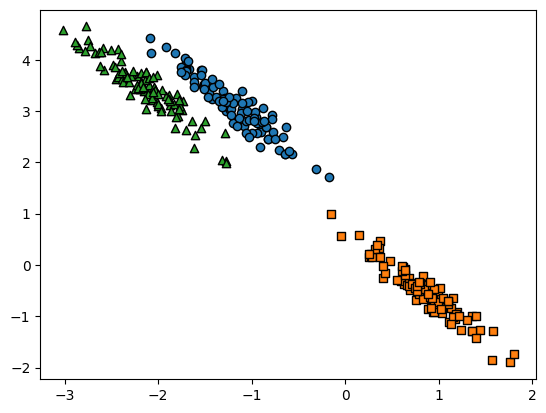

In [5]:
from sklearn.datasets import make_blobs

# mak은_blobs()로 300개의 데이터 세트, 3개의 군집 세트, cluster_std=0.5를 만듦.
X, y = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=0.5, random_state=0)

# 길게 늘어난 타원형의 데이터 세트를 생성하기 위해 변환함.
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)
# feature 데이터 세트와 make_blobs( )의 y 결괏값을 DataFrame으로 저장
clusterDF = pd.DataFrame(data=X_aniso, columns=['ftr1','ftr2'])
clusterDF['target'] = y
# 생성된 데이터 세트를 target별로 다른 마커로 표시해 시각화함
visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

* 데이터 세트에서는 KMeans의 군집화 정확성이 떨어지게 됩니다.
* KMeans가 위 데이터 세트를 어떻게 군집화하는지 확인해 보겠습니다

/tmp/ipython-input-3189151562.py:26: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k',


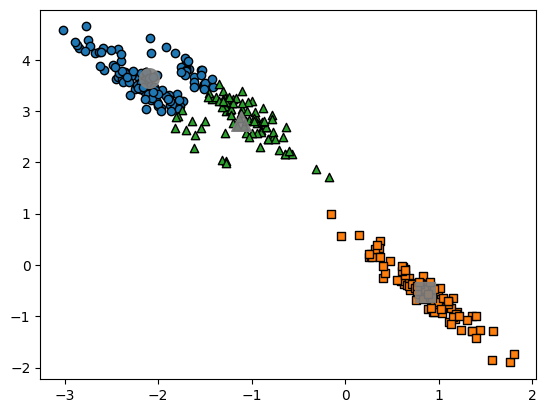

In [6]:
# 3개의 군집 기반 Kmeans를 X_aniso 데이터 세트에 적용
kmeans = KMeans(3, random_state=0)
kmeans_label = kmeans.fit_predict(X_aniso)
clusterDF['kmeans_label'] = kmeans_label

visualize_cluster_plot(kmeans, clusterDF, 'kmeans_label', iscenter=True)

* KMeans로 군집화를 수행할 경우, 주로 원형 영역 위치로 개별 군집화가 되면서 원하는 방향으로 구성되지 않음을 알 수 있습니다.
* KMeans가 평균 거리 기반으로 군집화를 수행하므로 같은 거리상 원형으로 군집을 구성하면서 위와 같이 길쭉한 방향으로 데이터가 밀접해 있을 경우에는 최적의 군집화가 어렵습니다.
* 이번에는 GMM으로 군집화를 수행해 보겠습니다

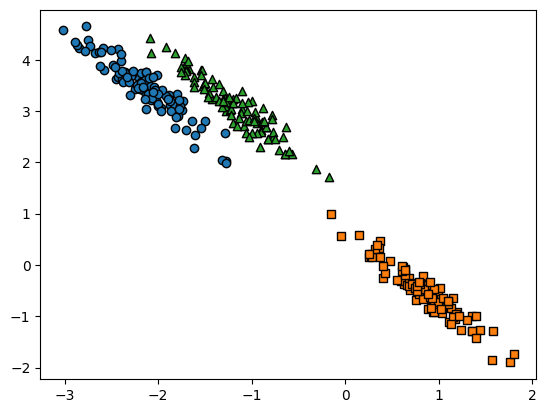

In [7]:
# 3개의 n_components 기반 GMM을 X_aniso 데이터 세트에 적용
gmm = GaussianMixture(n_components=3, random_state=0)
gmm_label = gmm.fit(X_aniso).predict(X_aniso)
clusterDF ['gmm_label'] = gmm_label

# GaussianMixture는 cluster_centers_ 속성이 없으므로 iscenter를 False로 설정.
visualize_cluster_plot(gmm, clusterDF, 'gmm_label', iscenter=False)

* 데이터가 분포된 방향에 따라 정확하게 군집화됐음을 알 수 있습니다.
* GMM은 K-평균과 다르게 군집의 중심 좌표를 구할 수 없기 때문에 군집 중심 표현이 visualize_cluster_plot( )에서 시각화되지 않습
니다.
* make_blobs()의 target 값과 KMeans, GMM의 군집 Label 값을 서로 비교해 위와 같은 데이터 세트에서 얼만큼의 군집화 효율 차이가 발생하는지 확인해 보겠습니다.

In [8]:
print('### KMeans Clustering ###')
print(clusterDF.groupby('target')['kmeans_label'].value_counts())
print('\n### Gaussian Mixture Clustering ###')
print(clusterDF.groupby('target')['gmm_label'].value_counts())

### KMeans Clustering ###
target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: count, dtype: int64

### Gaussian Mixture Clustering ###
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64


* KMeans의 경우 군집 1 번만 정확히 매핑됐지만, 나머지 군집의 경우 target 값과 어긋나는 경우가 발생하고 있습니다.
* 하지만 GMM의 경우는 군집이 target 값과 잘 매핑돼 있습니다.
* 이처럼 GMM의 경우는 KMeans보다 유연하게 다양한 데이터 세트에 잘 적용될 수 있다는 장점이 있습니다.
* 하지만 군집화를 위한 수행 시간이 오래 걸린다는 단점이 있습니다.